# Analytische beschouwing van onverzadigde zone in een dijk

Naar aanleiding van [publicatie 'Percolatie door dikke onverzadigde zones – Munsflow versus Kinematic Wave'](https://nhv.nu/kennis/stromingen/percolatie-door-dikke-onverzadigde-zones-munsflow-versus-kinematic-wave/) wordt een analyse opgezet voor percolatie door de onverzadigde zone van dijken.

In de publicatie wordt het volgende geschreven: <i>"Het duurt maanden tot jaren voordat het neerslagoverschot een dikke onverzadigde zone heeft doorlopen. Munsflow en Kinematic Wave (KW) zijn twee methoden om deze door de Richards-vergelijking beschreven percolatie efficiënt te berekenen. [..] Deze relatief onbekende methoden, worden in dit artikel naast elkaar gezet en vergeleken."</i>

Deze notebook bevat de uitgangspunten voor de toepassing in dijken bij Scheldestromen.


# Initialisatie

In [1]:
import hydropandas as hpd
import matplotlib.pyplot as plt

import pandas as pd
import os

import numpy as np

import logging
logging.basicConfig(level=logging.INFO)

In [2]:
hpd.__version__

'0.18.1'

In [3]:
import levee_munsflow_kw_helper as lmkw

In [4]:
DATA_DIR = r'..\data\\'

In [5]:
do_run_long_functions = False

# Gegevens

## Neerslag

Langjarige grondwaterreeksen starten in augustus 2022. Daarom neerslag sindsdien downloaden.

In [6]:
start = pd.Timestamp('2022-08-01')
end = pd.Timestamp('2026-09-01')
stn = 340 # Woensdrecht Airport
fn_precip = DATA_DIR + f'precip_{stn}_{start:%Y%m%d}_{end:%Y%m%d}.json'

if not os.path.exists(fn_precip):
    precip = hpd.PrecipitationObs.from_knmi(stn=stn, start=start, end=end, interval='hourly')
    precip.to_json(fn_precip)
else:
    precip = hpd.read_json(fn_precip)


<Axes: title={'center': 'Hourly precipitation at KNMI station WOENSDRECHT\nUursom van de neerslag (in m) (0 voor <0.05mm) '}>

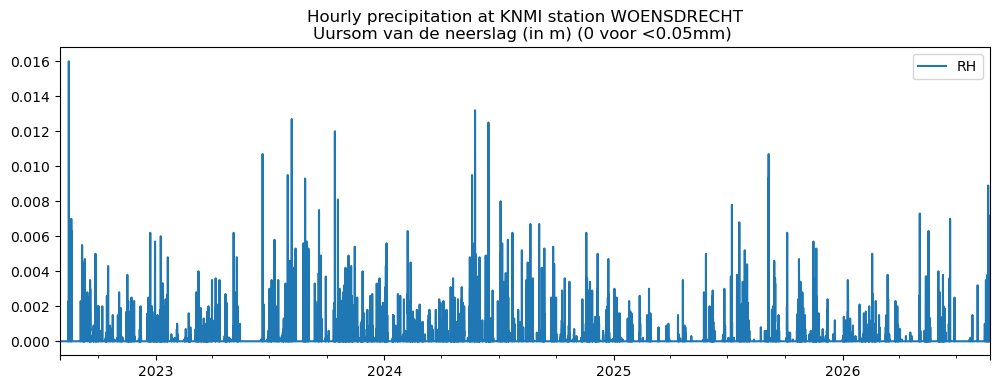

In [7]:
precip.plot(figsize=(12, 4), title=f"Hourly precipitation at KNMI station {precip.meta['location']}\n{precip.meta['RH'].split(r'/')[0]}")

## Doodtij 

Momenten van doodtij downloaden voor eventuele doorwerking in grondwaterstanden.

Data voorbereid via `N27-2 repo: data\areaal\doodtij.ipynb`.

In [8]:
df_doodtij = pd.read_csv(DATA_DIR + 'doodtij.csv', parse_dates=['datum_tijd', 'doodtij_verwachting', 'doodtij_verwachting_localize'],)
df_doodtij['doodtij_verwachting_localize'] = pd.to_datetime(df_doodtij['doodtij_verwachting_localize'], utc=True, errors='coerce')

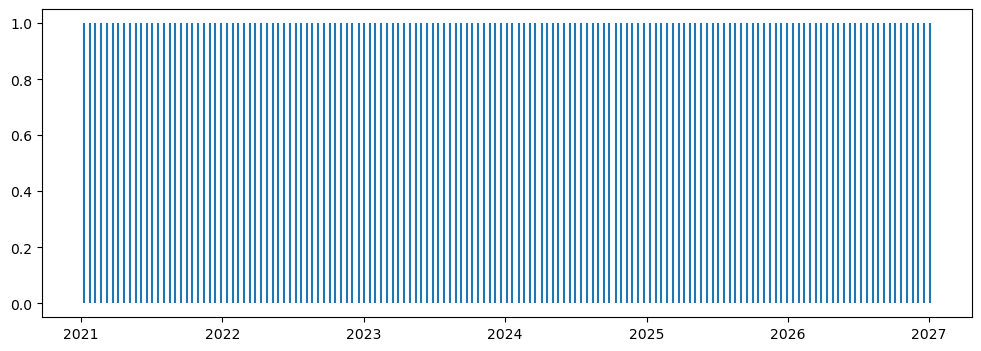

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.vlines(df_doodtij['doodtij_verwachting_localize'], ymin=0, ymax=1, label='Doodtij verwachting')

## Peilbuizen

Data voorbereid via `N27-2 repo: data\prepare\pbs-oc-collectie.ipynb`, zip gekopieerd van `N27-2 repo: data\obs\json\json.zip`.

In [10]:
obs_gws = lmkw.json_to_hpd(DATA_DIR + 'gws_json.zip')
col_gwl = 'gwl_mnap'

JSON inlezen:   0%|          | 0/96 [00:00<?, ?bestand/s]

INFO:root:JSON files read: 96
INFO:root:Obs created: 96
INFO:root:ObsCollection created with 96 Obs objects


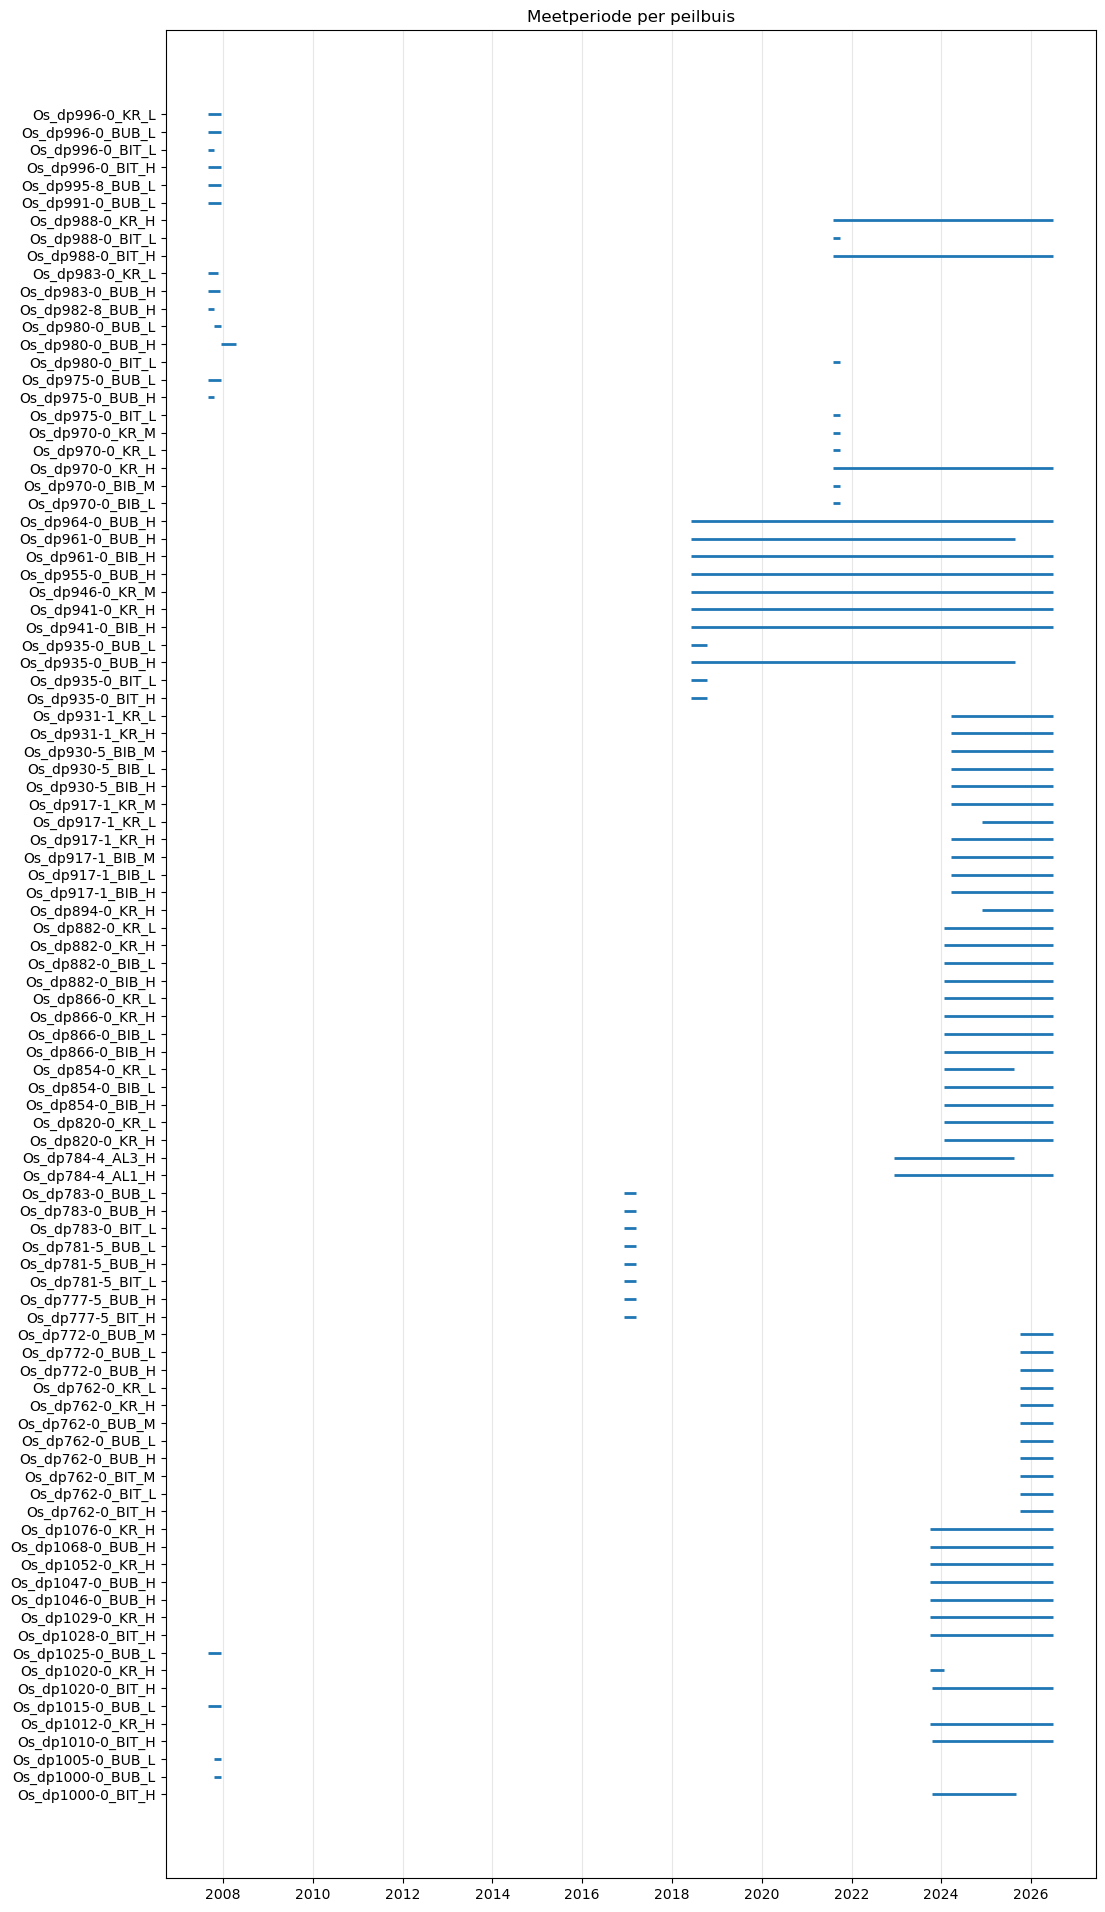

In [11]:
df_first_last = obs_gws.stats.get_first_last_obs_date().copy()

fig, ax = plt.subplots(figsize=(12, max(4, 0.25 * len(df_first_last))))
ax.hlines(
    y=df_first_last.index,
    xmin=df_first_last['date_first_measurement'],
    xmax=df_first_last['date_last_measurement'],
    color="tab:blue",
    linewidth=2
)
ax.set_title("Meetperiode per peilbuis")
ax.grid(True, axis="x", alpha=0.3)

## Profielen

Data gekopieerd van `geolookup repo: docs\examples\N27-2_data\table_profielen_Os_dp725-1080.csv`.

In [12]:
df_profiles = pd.read_csv(DATA_DIR + 'table_profielen_Os_dp725-1080.csv')
# voorbeeld van data voor 'bin' and 'kruin'
df_profiles.loc[:, ['dp'] + df_profiles.columns[df_profiles.columns.str.contains('bin|kruin')].to_list()].head()

,dp,xmv.bin,xkruin.1,xkruin.2,ymv.bin,ykruin.1,ykruin.2
0,725.0,-91.13,-3.404,2.238,1.203,6.39,6.22
1,726.0,-200.88,-2.953,-0.385,1.329,6.43,6.41
2,727.0,-51.22,-2.084,-0.067,1.342,6.51,6.43
3,728.0,-201.00,-2.665,-0.833,1.158,6.45,6.37
4,729.0,-201.00,-2.764,-0.546,1.222,6.46,6.42


# Analyse

## Neerslag

Analyse van de verschillende jaren. Gekozen om cummulatieve neerslag sinds 1 augustus te plotten, tot 31 juli jaar er op. In die periode stijgt namelijk de grondwaterstand in de dijk.

In [13]:
cumulative_start_month = 8
month_name = ['januari', 'februari', 'maart', 'april', 'mei', 'juni', 'juli', 'augustus', 'september', 'oktober', 'november', 'december'][cumulative_start_month - 1]

precip_df = precip.copy()
precip_df['date'] = precip_df.index
precip_df['year'] = precip_df['date'].dt.year
precip_df['month'] = precip_df['date'].dt.month
precip_df['season_year'] = precip_df['year']
precip_df.loc[precip_df['month'] < cumulative_start_month, 'season_year'] -= 1
precip_df['cumulative'] = precip_df.groupby('season_year')[precip.columns[0]].cumsum()

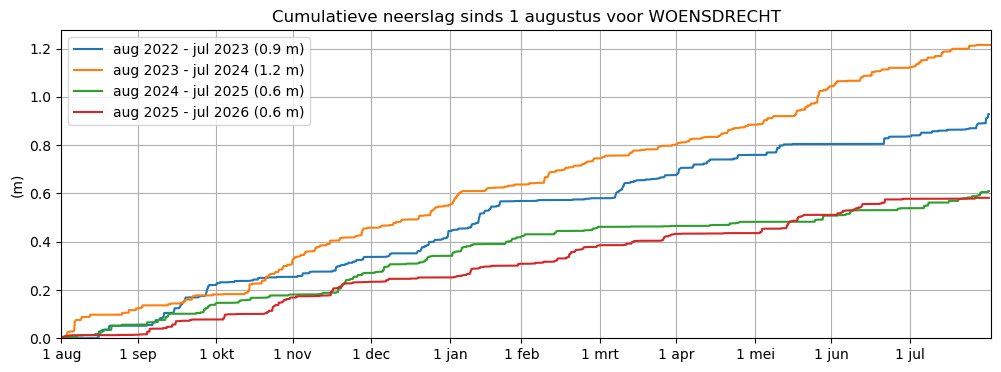

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
for year, group in precip_df.groupby('season_year'):
    days_since_start = (group['date'] - group['date'].iloc[0]).dt.total_seconds() / 86400
    if year < 2026:
        ax.plot(days_since_start, group['cumulative'], label=f'aug {year} - jul {year+1} ({group["cumulative"].iloc[-1]:.1f} m)')
ax.set_xticks([0, 30, 61, 91, 122, 153, 181, 212, 242, 273, 303, 334])
ax.set_xticklabels(['1 aug', '1 sep', '1 okt', '1 nov', '1 dec', '1 jan', '1 feb', '1 mrt', '1 apr', '1 mei', '1 jun', '1 jul'])

ax.set_title(f'Cumulatieve neerslag sinds 1 {month_name} voor {precip.meta["location"]}')
ax.set_ylabel('(m)')
ax.legend()
ax.set_xlim(0, 366)
ax.set_ylim(bottom=0)
ax.grid(True)

Voor normomstandigheden van waterkeringen is langdurige regen relevant. Want dan zijn omstandigheden enigszins vergelijkbaar met overslag door golven.

Daarom grafiek maken met aantal uur regen per dag (blauw). Daarin met oranje aangegeven wanneer er ook veel neerslag valt. Vervolgens met de verticale lijn aangegeven of dat ook in de natte periode van het jaar valt.

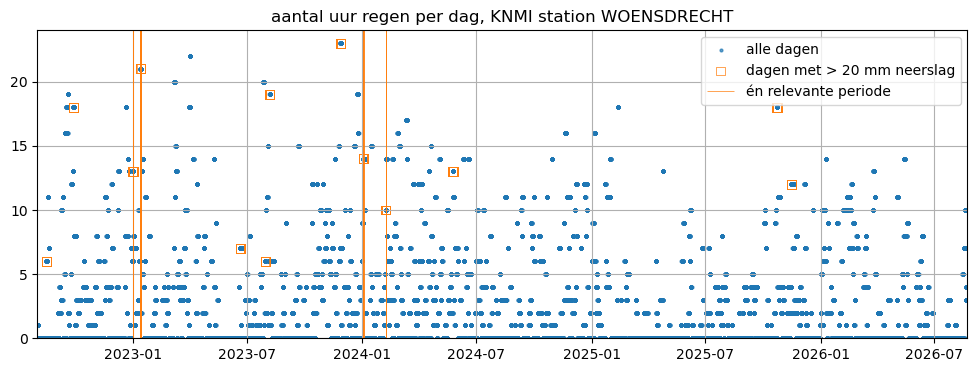

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
ylims = [0, 24]

# plot het aantal uur dat het per dag regent
dt_hours = precip_df.index.to_series().diff().dt.total_seconds().div(3600).fillna(1.0)
precip_df['hours_of_rain'] = ((precip_df[precip.columns[0]] > 0).astype(float) * dt_hours).groupby(precip_df.index.normalize()).transform('sum')
ax.scatter(x=precip_df['date'], y=precip_df['hours_of_rain'], s=4, alpha=0.7, label='alle dagen')

# natte dagen
precip_threshold = 20 / 1000 
precip_df_filtered = precip_df[precip_df[precip.columns[0]].groupby(precip_df.index.normalize()).transform('sum') > precip_threshold]
ax.scatter(
    x=precip_df_filtered['date'],
    y=precip_df_filtered['hours_of_rain'],
    s=40,
    marker='s', facecolors='none', edgecolors='tab:orange',  linewidths=0.5,
    label=f'dagen met > {precip_threshold * 1000:.0f} mm neerslag'
)

# in natte periode
precip_df_filtered_highlight = precip_df_filtered[(precip_df_filtered['month'].isin([1, 2, 3, 12]))]
ax.vlines(x=precip_df_filtered_highlight['date'], ymin=ylims[0], ymax=ylims[1], color='tab:orange', linewidth=0.5, label=f'én relevante periode')

# layout
ax.set_xlim([precip_df['date'].min(), precip_df['date'].max()])
ax.set_ylim(ylims)
ax.set_title(f'aantal uur regen per dag, KNMI station {precip.meta['location']}')
ax.grid(True)
ax.legend()


## Conclusie voor neerslag

- periode aug 2022-juli 2023; en aug 2023-juli 2024 zijn het natst (van de beschikbare jaren met waargenomen grondwaterstanden)
- in beide periodes liggen rond de jaarwisseling twee dagen met meer dan 20 mm neerslag

# Peilbuizen

In [16]:
if do_run_long_functions:
    for raai, oc_raai in obs_gws.groupby('raai_plot'): # .iloc[:10]
        # als in oc_raai alle rijen in screen_top < -3, sla dan de plot over
        if (oc_raai['screen_top'] < -3).all():
            logging.info(f"Skipping raai_plot {raai} because all screen_top < -3")
            continue
        
        oc_raai = lmkw.add_offset_for_close_points(oc_raai)

        fig, [ax_section, ax_obs] = oc_raai.plots.section_plot(
            cols=[col_gwl],
            section_colname_x='distance_to_ref_plot',
            section_label_x='afstand referentielijn (m)',
            plot_well_layout_markers=True,
        )
        ax_obs.tick_params(axis='x', labelrotation=0)
        ax_obs.set_ylabel('m NAP')
        ax_section.set_ylabel('m NAP')

        # bepaal x-limieten van de tijd-as als timestamps
        x_start, x_end = lmkw.ax_lim_as_dates(ax_obs)
        
        # add new subplot, direct below ax_obs, with same x-limits, for precipitation
        ax_precip = ax_obs.inset_axes([0, -0.4, 1, 0.3],)
        ax_precip.plot(
            precip_df.loc[x_start:x_end, 'date'], 
            precip_df.loc[x_start:x_end, 'cumulative'], 
            color='tab:red', 
            linewidth=1.5, 
            label=f'cummulatief sinds 1 {month_name}')
        ax_precip.set_ylabel('neerslag (mm)')
        ax_precip.set_ylim(bottom=0)
        ax_precip.set_xlim([x_start, x_end])
        ax_precip.grid(True)

        lmkw.plot_dates_as_vline(
            precip_df_filtered,
            [ax_obs, ax_precip],
            label=f'dagen met > {precip_threshold * 1000:.0f} mm neerslag',
            color='blue'
            )
        lmkw.plot_dates_as_vline(
            precip_df_filtered_highlight,
            [ax_obs, ax_precip],
            label=f'én relevante periode',
            color='orange'
            )

        lmkw.short_legend_precip(ax_precip)
        
        threshold_additional_plot = pd.Timestamp('2022-08-01')
        if (oc_raai.stats.dates_first_obs.min() < threshold_additional_plot) & (oc_raai.stats.dates_last_obs.max() > threshold_additional_plot):
            ax_zoom = ax_precip.inset_axes([0, -1, 1, 0.9],)
            for index, row in oc_raai.iterrows():
                df_plot = row.obs.loc[threshold_additional_plot:]
                ax_zoom.plot(df_plot.index, df_plot[col_gwl], linewidth=1.5)
            
        fig.suptitle(f"Raai {raai}")
        fig.tight_layout()
        fig.savefig(fr"plots\raai_{raai.replace('.', '_')}.png", dpi=300)

        plt.close()


Bovenstaande loop voor plotten wordt nog een keer gedraaid, maar nu worden peilbuizen in het watervoerende pakket weggelaten. Via `filter_threshold`. Zo verstoort de getijdereeks niet de freatische reeks.

In [17]:
filter_threshold = -2

if do_run_long_functions: 

    for raai, oc_raai in obs_gws.groupby('raai_plot'): # .iloc[:10]
        # als in oc_raai alle rijen in screen_top < -3, sla dan de plot over
        if (oc_raai['screen_top'] < filter_threshold).all():
            logging.info(f"Skipping raai_plot {raai} because all screen_top < {filter_threshold}")
            continue

        if oc_raai['screen_top'].min() < filter_threshold:
            logging.info(f"Filtering raai_plot {raai} to remove screen_top < {filter_threshold}")
            oc_raai = oc_raai.loc[oc_raai.screen_top > filter_threshold]
        else:
            continue

        oc_raai = lmkw.add_offset_for_close_points(oc_raai)

        fig, [ax_section, ax_obs] = oc_raai.plots.section_plot(
            cols=[col_gwl],
            section_colname_x='distance_to_ref_plot',
            section_label_x='afstand referentielijn (m)',
            plot_well_layout_markers=True,
        )
        ax_obs.tick_params(axis='x', labelrotation=0)
        ax_obs.set_ylabel('m NAP')
        ax_section.set_ylabel('m NAP')

        # bepaal x-limieten van de tijd-as als timestamps
        x_start, x_end = lmkw.ax_lim_as_dates(ax_obs)
        
        # add new subplot, direct below ax_obs, with same x-limits, for precipitation
        ax_precip = ax_obs.inset_axes([0, -0.4, 1, 0.3],)
        ax_precip.plot(
            precip_df.loc[x_start:x_end, 'date'], 
            precip_df.loc[x_start:x_end, 'cumulative'], 
            color='tab:red', 
            linewidth=1.5, 
            label=f'cummulatief sinds 1 {month_name}')
        ax_precip.set_ylabel('neerslag (mm)')
        ax_precip.set_ylim(bottom=0)
        ax_precip.set_xlim([x_start, x_end])
        ax_precip.grid(True)

        lmkw.plot_dates_as_vline(
            precip_df_filtered,
            [ax_obs, ax_precip],
            label=f'dagen met > {precip_threshold * 1000:.0f} mm neerslag',
            color='blue'
            )
        lmkw.plot_dates_as_vline(
            precip_df_filtered_highlight,
            [ax_obs, ax_precip],
            label=f'én relevante periode',
            color='orange'
            )

        lmkw.short_legend_precip(ax_precip)
        
        threshold_additional_plot = pd.Timestamp('2022-08-01')
        if (oc_raai.stats.dates_first_obs.min() < threshold_additional_plot) & (oc_raai.stats.dates_last_obs.max() > threshold_additional_plot):
            ax_zoom = ax_precip.inset_axes([0, -1, 1, 0.9],)
            for index, row in oc_raai.iterrows():
                df_plot = row.obs.loc[threshold_additional_plot:]
                ax_zoom.plot(df_plot.index, df_plot[col_gwl], linewidth=1.5)
            
        fig.suptitle(f"Raai {raai}, weggelaten peilbuizen met screen_top < {filter_threshold}")
        fig.tight_layout()
        fig.savefig(fr"plots\raai_{raai.replace('.', '_')}_filter_boven_{filter_threshold}.png", dpi=300)

        plt.close()


Van relevante peilbuizen een detail plot maken. Daarbij ook de doodtij momenten plotten, om te beoordelen wat de impact is van doodtij/springtij op de reeks. Voor de huidige analyse zoeken we in eerste instantie peilbuizen met geen of nauwelijks een interactie met doodtij/springtij. Want dat maakt de analyse makkelijker.

In [18]:
for raai, oc_raai in obs_gws.groupby('raai_plot'): # .iloc[:10]
    target_raai = ['os866', 'os882', 'os935', 'os941', 'os961', 'os970', 'os982', 'os988', 'os1000', 'os1010', 'os1012', 'os1020', 'os1028']
    raai_norm = ''.join(ch for ch in raai.lower() if ch.isalnum())  # e.g. "Os_996.0" -> "os9960"

    if not any(target in raai_norm for target in target_raai):
        continue

    # verwijder diepe filters
    oc_raai = oc_raai.loc[oc_raai.screen_top > filter_threshold]

    #x_start = oc_raai.stats.dates_first_obs.min()
    #x_end = oc_raai.stats.dates_last_obs.max()
    x_start = pd.Timestamp('2022-08-01')  # for consistent x-axis across plots
    x_end  = pd.Timestamp('2026-08-01')
    
    oc_raai = lmkw.add_offset_for_close_points(oc_raai)

    fig, [ax_obs, ax_precip] = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    for index, row in oc_raai.iterrows():
        df_plot = row.obs.loc[x_start:x_end].dropna(subset=[col_gwl])
        ax_obs.plot(df_plot.index, df_plot[col_gwl], linewidth=1.5)

    lmkw.plot_doodtij(
        ax_obs,
        df_doodtij
    )

    ax_precip.plot(
        precip_df.loc[x_start:x_end, 'date'], 
        precip_df.loc[x_start:x_end, 'cumulative'], 
        color='tab:red', 
        linewidth=1.5, 
        label=f'cummulatief sinds 1 {month_name}')
    ax_precip.set_ylabel('neerslag (mm)')
    ax_precip.set_ylim(bottom=0)
    ax_precip.set_xlim([x_start, x_end])
    ax_precip.grid(True)

    lmkw.plot_dates_as_vline(
        precip_df_filtered,
        [ax_obs, ax_precip],
        label=f'dagen met > {precip_threshold * 1000:.0f} mm neerslag',
        color='blue'
        )
    lmkw.plot_dates_as_vline(
        precip_df_filtered_highlight,
        [ax_obs, ax_precip],
        label=f'én relevante periode',
        color='orange'
        )

    ax_obs.set_xlim([x_start, x_end])
        
    fig.suptitle(f"Detail raai {raai} voor filter boven {filter_threshold} m NAP")
    fig.tight_layout()
    fig.savefig(fr"plots\detail_raai_{raai.replace('.', '_')}.png", dpi=300)

    plt.close()


# Selectie peilbuizen

Op basis van bovenstaande plots geschikte locaties gezocht. 

| dp | waarom relevant | gebruiken? | motivatie |
| ------------- |-------------| -------------| -------------|
| 866 | bij kruin rustige reeks, start wel pas najaar 2025. Binnenberm is juist tot voorjaar 2025 gemeten. Die heeft effect van doodtij cyclus | Nee | KR: te kort, BIB doodtij effect  |
| 882| rustige reeks bij KR en en BIB. Nadeel is start in voorjaar 2024, dus mist natste jaren. | Kan | Meting sinds jan 2024, dus mist natste jaren. Heeft geen binnenberm, meteen binnenteen. | 
| 935| reeks sinds zomer 2022 | Nee | Effect op doodtij cyclus | 
| 941 | vanaf december 2022, vanaf najaar 2023 twee filters | Ja | Reeks in natste jaren, KR en BIB, wel klein beetje doodtij effect. Mooie versterking in zand met echte binnenberm er bij. | 
| 961 | vanaf december 2022, vanaf najaar 2023 twee filters | Nee | Te veel doodtij effect | 
| 970 | reeks sinds zomer 2022 | Nee | Effect op doodtij cyclus | 
| 982.8 | alleen metingen in 2007. Heeft flinke piek in oktober 2007. Neerslag of buitenwater? | Nee | Oorsprong nalopen, en BUB lijkt minder relevant. | 
| 988 | reeks sinds 2022 | Nee | Effect op doodtij cyclus | 
| 1000 | reeks BIT met scherpe en directe stijging (10 cm) op hevige neerslag | Nee | Effect op doodtij cyclus | 
| 1010 | reeks BIT met scherpe en directe stijging (10 cm) op hevige neerslag | Kan | Nog niet doen, want geen reeks bij kruin | 
| 1012 | locatie met gws tot NAP +2,8 m, is de hoogste, maar met hoog achterland wel unieke locatie | Kan | Nog niet doen, want dit is een extreme situatie, moet niet de 'benchmark' worden van Zeeuwse dijken. |
| 1020 | reeks bij BIT sinds najaar 2023, rustig. Bij KR alleen hele hoge peilbuis (filter NAP +3 m), die staat droog | Kan | Nog niet doen, want geen reeks bij kruin |
| 1028 | reeks bij BIT sinds najaar 2023, rustig, wel relatief diep filter (filter NAP -2,5 m) | Nee | Relatief diep filter, alleen BIT en korte reeks |

# Uitgangspunten voor `dp941`

In [19]:
dp = 941

## Locatie

Overzichtskaart met rode streep bij `dp941`.

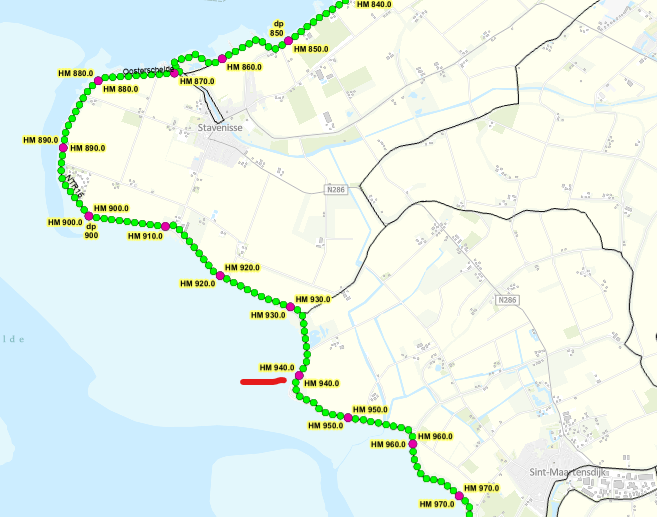

Detail kaart met rood omcirkeld de locatie. Blauwe pijl waar gemaal loost op Oosterschelde.

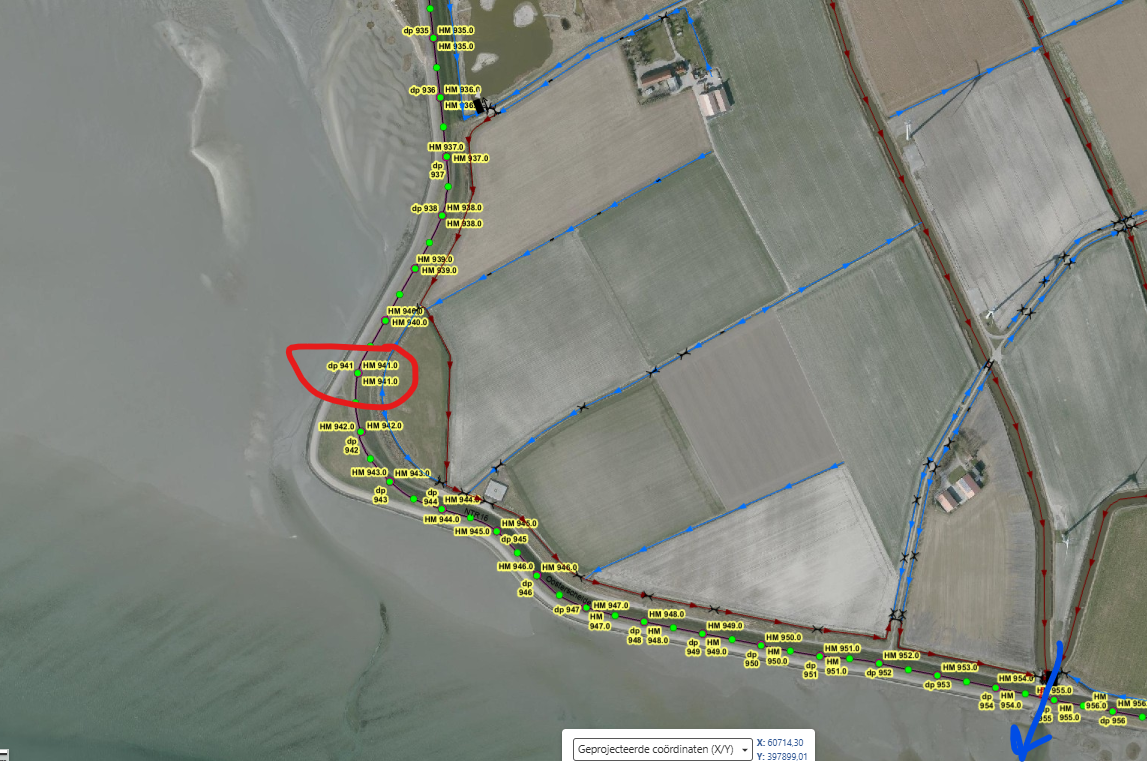

## Bodemopbouw

Via `geolookup` hiervoor [doorsnede gemaakt](../data/os941/profiel_dp0940__plusmin2_2plots.html).

Boringen en sonderingen ook als PDF in map gezet: `../data/os941/`.

## Watersysteem

Streefpeil: zomer NAP -2,1 m; winter NAP -2,3 m.

In [20]:
zp = -2.3
wp = -2.1

## Freatische lijn

Wat is de onderzijde van de onverzadigde zone?

In [21]:
obs_gws_dp = obs_gws.loc[obs_gws.dp == dp]
obs_gws_dp

,x,y,location,filename,source,unit,tube_nr,screen_top,screen_bottom,ground_level,...,distance_to_ref,filter_letter,tube_bottom,traject,timeseries_id,in_analysis,remark_obs,raai_plot,plot_dp,plot_x
name,,,,,,,,,,,,,,,,,,,,,
Os_dp941-0_BIB_H,60822.199,397424.611,18B_034,[\\ws.local\share\wk\ProjectenWaterkeringen\Be...,Diver CSV,,10,-0.277,-1.277,2.223,...,-27.174378,H,-2.277,"onbekend, niet gegeven in Boring2013",18B_034H,NaN,handmeting 7 juni 2024 niet beschouwen; VELDAC...,Os_941.0,Os_941.0,-7.174378
Os_dp941-0_KR_H,60796.896,397430.845,18B_035,[\\ws.local\share\wk\ProjectenWaterkeringen\Be...,Diver CSV,,10,0.412,-0.588,7.912,...,-1.115152,H,-1.588,"onbekend, niet gegeven in Boring2013",18B_035H,NaN,handmeting 7 juni 2024 niet beschouwen,Os_941.0,Os_941.0,18.884848


In [22]:
mean_obs = obs_gws_dp.stats.mean_in_period().mean()

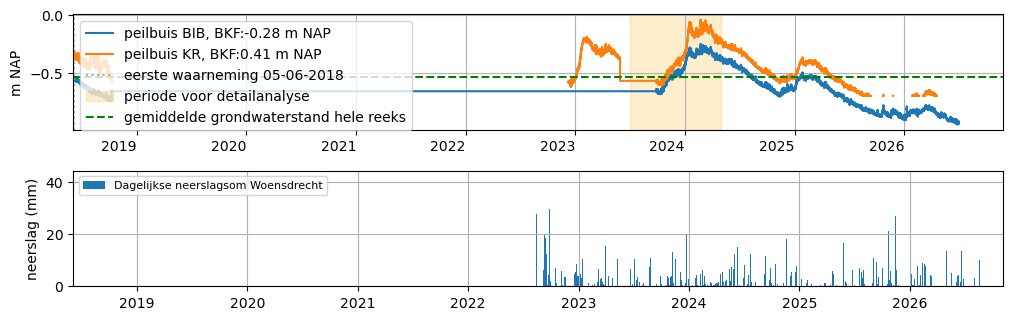

In [23]:
fig, axes = lmkw.plot_pb_precip(
        obs_gws_dp,
        precip_df,
)
start=pd.Timestamp('2023-07-01')
end=pd.Timestamp('2024-05-01')

axes[0].axvspan(start, end, color='orange', alpha=0.2, label='periode voor detailanalyse')
axes[0].axhline(y=mean_obs, color='green', linestyle='--', label='gemiddelde grondwaterstand hele reeks')
axes[0].legend()

gemiddelde grondwaterstand Osdp941 01-01-2024 tot 01-04-2024


C:\Users\HMEUW\AppData\Local\Temp\ipykernel_25476\1092266983.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  axes[0].plot(period_unsat, [avg_obs]*2, color='green', linestyle=':', label=label_unsat)


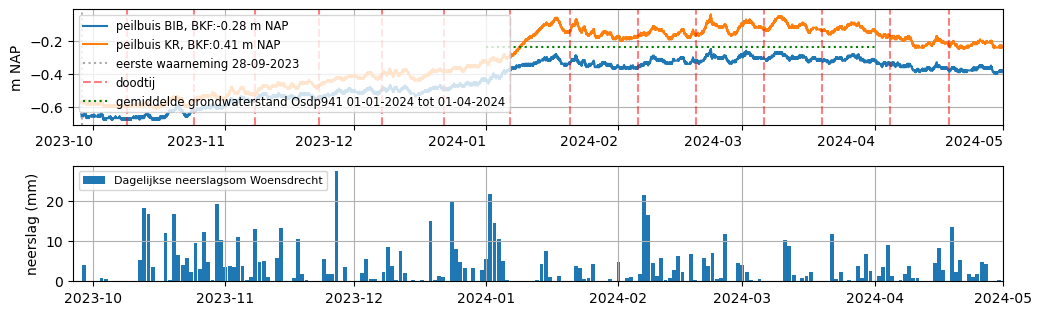

In [24]:
fig, axes = lmkw.plot_pb_precip(
        obs_gws_dp,
        precip_df,
        df_doodtij=df_doodtij,
        start=start,
        end=end,
)
period_unsat = [pd.Timestamp('2024-01-01'), pd.Timestamp('2024-04-01')]
avg_obs = obs_gws_dp.stats.mean_in_period(period_unsat[0], period_unsat[1]).mean()
label_unsat = (
        f"gemiddelde grondwaterstand "
        f"{'/'.join(map(str, obs_gws_dp.region.unique()))}"
        f"dp{'/'.join(map(lambda v: str(int(v)), obs_gws_dp.dp.unique()))} "
        f"{period_unsat[0].strftime('%d-%m-%Y')} tot {period_unsat[1].strftime('%d-%m-%Y')}"
)
print(label_unsat)
axes[0].plot(period_unsat, [avg_obs]*2, color='green', linestyle=':', label=label_unsat)
axes[0].legend(fontsize='small', loc='upper left')

## Profiel
Verschillende bronnen in profiel plotten. Op drie locaties de dikte van de onverzadigde zone uitrekenen.

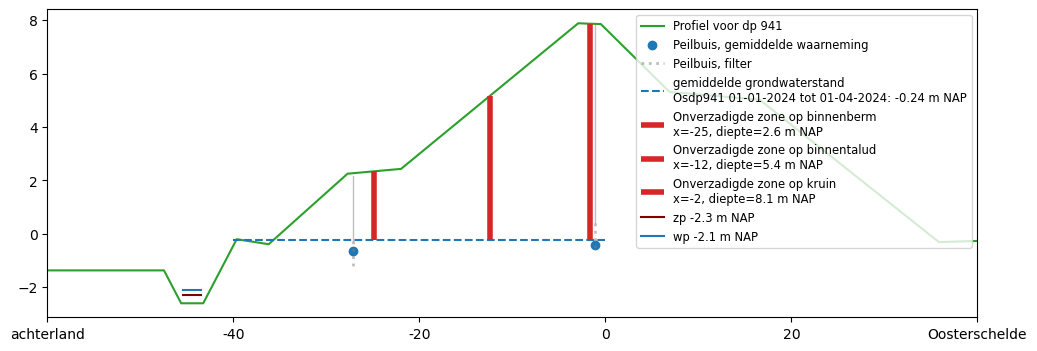

In [25]:
x_vals, y_vals, closest_dp_profile = lmkw.select_surfacelevelprofile(
    dp_center=dp,
    df_profiles=df_profiles,
    delta_dp=0,
    region='Os'
)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x_vals, y_vals, color='tab:green', label=f'Profiel voor dp {dp}')

# peilbuis
for index, row in obs_gws_dp.iterrows():
    ax.scatter(row.distance_to_ref, row.obs[col_gwl].mean(), color='tab:blue', label=f'Peilbuis, gemiddelde waarneming')
    ax.plot([row.distance_to_ref]*2, [row.screen_top, row.screen_bottom], color='tab:gray', ls=':', lw=2, alpha=0.5, label=f'Peilbuis, filter')
    ax.plot([row.distance_to_ref]*2, [row.tube_top, row.screen_top], color='tab:gray', ls='-', lw=1, alpha=0.5, label=f'_Peilbuis, filter')

# onverzadigde zone
x_unsat = [-40, 0]
ax.plot(x_unsat, [avg_obs]*2, color='tab:blue', ls='--', label=f"{label_unsat.replace('stand ', 'stand\n')}: {avg_obs:.2f} m NAP")

# diktes berekenen
x_model = [
    df_profiles.loc[df_profiles['dp'] == closest_dp_profile, ['xberm.1a', 'xberm.1b']].iloc[0].mean(),
    df_profiles.loc[df_profiles['dp'] == closest_dp_profile, ['xberm.1b', 'xkruin.1']].iloc[0].mean(),
    df_profiles.loc[df_profiles['dp'] == closest_dp_profile, ['xkruin.1', 'xkruin.2']].iloc[0].mean()
    ]
position = ['binnenberm', 'binnentalud', 'kruin']
groundlevel = []
bottom_unsat = []
depth_unsat = []

for x, pos in zip(x_model, position):
    groundlevel.append(np.interp(x, x_vals, y_vals))
    bottom_unsat.append(avg_obs)
    depth_unsat.append(groundlevel[-1] - bottom_unsat[-1])
    ax.plot([x]*2, [bottom_unsat[-1], groundlevel[-1]], color='tab:red', lw=4,
            solid_capstyle='butt',
            label=f'Onverzadigde zone op {pos}\nx={x:.0f}, diepte={depth_unsat[-1]:.1f} m NAP')

# waterpeilen
mid_teensloot = df_profiles.loc[df_profiles['dp'] == closest_dp_profile, ['xsloot.1c', 'xsloot.1d']].iloc[0].mean()
x_teensloot = [mid_teensloot - 1, mid_teensloot + 1]
ax.plot(x_teensloot, [zp]*2, color='maroon', label=f'zp {zp} m NAP')
ax.plot(x_teensloot, [wp]*2, color='tab:blue', label=f'wp {wp} m NAP')

# layout
ax.set_xlim(-60, 40)
ax.set_xticks(ax.get_xticks().tolist())
ax.set_xticklabels(['achterland' if i == ax.get_xticks().tolist()[0] else 'Oosterschelde' if i == ax.get_xticks().tolist()[-1] else str(int(i)) for i in ax.get_xticks().tolist()])

# legenda
handles, labels = ax.get_legend_handles_labels()
unique = {}
for h, l in zip(handles, labels):
    if l and l != "_nolegend_" and l not in unique:
        unique[l] = h

ax.legend(unique.values(), unique.keys(), fontsize='small', loc='upper right')

df_unsat = pd.DataFrame({
    'x': np.array(x_model).round(0),
    'groundlevel': np.array(groundlevel).round(1),
    'bottom_unsat': np.array(bottom_unsat).round(1),
    'depth_unsat': np.array(depth_unsat).round(1),
    'position': position,
    'lithology': None,
    'staring_code': None,
    'remark': None,
    'depth_top_clay': None,
    'depth_model': None,
})

In [26]:
df_unsat['index_col'] = (
        f"{'/'.join(map(str, obs_gws_dp.region.unique()))}_"
        f"dp{'/'.join(map(lambda v: str(int(v)), obs_gws_dp.dp.unique()))}_" +
        df_unsat.position
)
df_unsat.set_index('index_col', inplace=True)
df_unsat

,x,groundlevel,bottom_unsat,depth_unsat,position,lithology,staring_code,remark,depth_top_clay,depth_model
index_col,,,,,,,,,,
Os_dp941_binnenberm,-25.0,2.3,-0.2,2.6,binnenberm,None,None,None,None,None
Os_dp941_binnentalud,-12.0,5.2,-0.2,5.4,binnentalud,None,None,None,None,None
Os_dp941_kruin,-2.0,7.9,-0.2,8.1,kruin,None,None,None,None,None


In `df_unsat` staan de geometrische kenmerken voor de onverzadigde zone op drie gekozen locaties. 

Deze nu aanvullen met de code uit de Staring reeks. Dat gebeurt handmatig via de boorstaten in `..\data\os941\`.

In [27]:
pos = 'Os_dp941_binnenberm'
df_unsat.at[pos, 'lithology'] = 'Lab classificatie.: Zand, matig fijn, zwak siltig grijs' 
df_unsat.at[pos, 'staring_code'] = 'O02' 
df_unsat.at[pos, 'depth_top_clay'] = 0
df_unsat.at[pos, 'remark'] = 'Lab classificatie geeft onder NAP -0,28 m grover zand, dat zit lager dan de onverzadigde zone.\nGeen kleibekleding, maar verharding van hoogovenslakken.' 

pos = 'Os_dp941_kruin'
df_unsat.at[pos, 'lithology'] = 'Veld classificatie:  Zand, matig fijn, zwak siltig, resten schelpen grijs-bruin; Lab classificatie.: Zand, matig grof, zwak siltig grijs' 
df_unsat.at[pos, 'staring_code'] = 'O05'
df_unsat.at[pos, 'depth_top_clay'] = 0.6
df_unsat.at[pos, 'remark'] = 'Broloket bevat veldclassificatie. Lab classificatie geeft grover zand. Die maatgevend gehouden boven veld classificatie.'

pos = 'Os_dp941_binnentalud'
df_unsat.at[pos, 'lithology'] = 'Geen boring beschikbaar' 
df_unsat.at[pos, 'staring_code'] = df_unsat.loc['Os_dp941_kruin', 'staring_code']
df_unsat.at[pos, 'depth_top_clay'] = 0.6
df_unsat.at[pos, 'remark'] = 'Kruin wordt aangehouden' 

df_unsat.depth_model = (df_unsat.depth_unsat - df_unsat.depth_top_clay).round(1)

In [28]:
df_unsat

,x,groundlevel,bottom_unsat,depth_unsat,position,lithology,staring_code,remark,depth_top_clay,depth_model
index_col,,,,,,,,,,
Os_dp941_binnenberm,-25.0,2.3,-0.2,2.6,binnenberm,"Lab classificatie.: Zand, matig fijn, zwak sil...",O02,"Lab classificatie geeft onder NAP -0,28 m grov...",0,2.6
Os_dp941_binnentalud,-12.0,5.2,-0.2,5.4,binnentalud,Geen boring beschikbaar,O05,Kruin wordt aangehouden,0.6,4.8
Os_dp941_kruin,-2.0,7.9,-0.2,8.1,kruin,"Veld classificatie: Zand, matig fijn, zwak si...",O05,Broloket bevat veldclassificatie. Lab classifi...,0.6,7.5


In [29]:
df_unsat.columns

Index(['x', 'groundlevel', 'bottom_unsat', 'depth_unsat', 'position',
       'lithology', 'staring_code', 'remark', 'depth_top_clay', 'depth_model'],
      dtype='str')

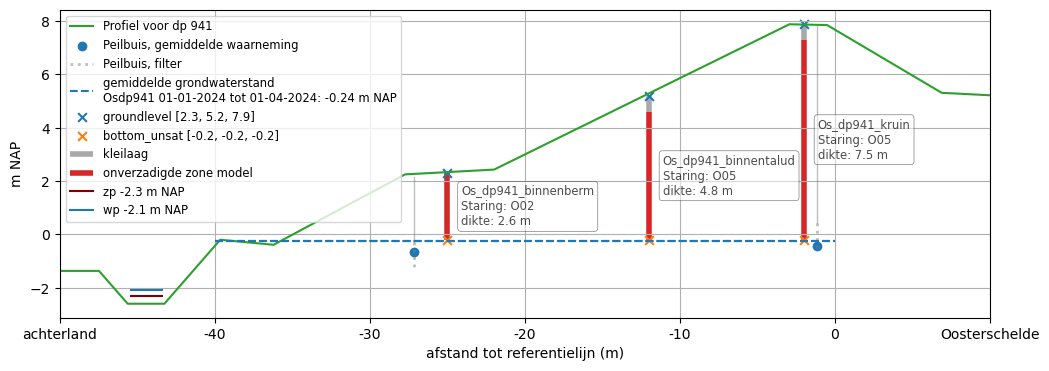

In [34]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x_vals, y_vals, color='tab:green', label=f'Profiel voor dp {dp}')

# peilbuis
for index, row in obs_gws_dp.iterrows():
    ax.scatter(
        row.distance_to_ref, row.obs[col_gwl].mean(), marker='o', 
        color='tab:blue', label=f'Peilbuis, gemiddelde waarneming')
    ax.plot(
        [row.distance_to_ref]*2, [row.screen_top, row.screen_bottom], 
        color='tab:gray', ls=':', lw=2, alpha=0.5, label=f'Peilbuis, filter')
    ax.plot(
        [row.distance_to_ref]*2, [row.tube_top, row.screen_top], 
        color='tab:gray', ls='-', lw=1, alpha=0.5, label=f'_Peilbuis, filter')

# onverzadigde zone
ax.plot(
    x_unsat, [bottom_unsat]*2, 
    color='tab:blue', ls='--', 
    label=f"{label_unsat.replace('stand ', 'stand\n')}: {avg_obs:.2f} m NAP")

for col in df_unsat.columns:
    if col in ['groundlevel', 'bottom_unsat', ]:
        ax.scatter(
            df_unsat.x, df_unsat[col], s=40, marker='x',
            label=f"{col} {df_unsat[col].round(2).to_list()}", zorder=1)
    elif col == 'depth_top_clay':
        ax.plot(
            [df_unsat.x.values]*2, [df_unsat.groundlevel, df_unsat.groundlevel - df_unsat[col]], 
            lw=4, color='darkgray', label='kleilaag', zorder=-100, solid_capstyle='butt',)
    elif col == 'depth_model':
        ax.plot(
            [df_unsat.x.values]*2, [df_unsat.groundlevel - df_unsat.depth_top_clay, df_unsat.bottom_unsat],
             lw=4, color='tab:red', label='onverzadigde zone model', zorder=-100, solid_capstyle='butt',)

for index, row in df_unsat.iterrows():
    ax.annotate(
        f"{index}\nStaring: {row['staring_code']}\ndikte: {row.depth_model} m",
        xy=(row['x'], np.mean([row.groundlevel - row.depth_top_clay, row.bottom_unsat])),
        xytext=(10, 0),
        textcoords='offset points',
        fontsize='small',
        color='black',
        alpha=0.7,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5, alpha=0.5),
        va='center',
    )

# waterpeilen
mid_teensloot = df_profiles.loc[df_profiles['dp'] == closest_dp_profile, ['xsloot.1c', 'xsloot.1d']].iloc[0].mean()
x_teensloot = [mid_teensloot - 1, mid_teensloot + 1]
ax.plot(x_teensloot, [zp]*2, color='maroon', label=f'zp {zp} m NAP')
ax.plot(x_teensloot, [wp]*2, color='tab:blue', label=f'wp {wp} m NAP')

# layout
ax.set_xlim(-50, 10)
ax.set_xticks(ax.get_xticks().tolist())
ax.set_xticklabels(['achterland' if i == ax.get_xticks().tolist()[0] else 'Oosterschelde' if i == ax.get_xticks().tolist()[-1] else str(int(i)) for i in ax.get_xticks().tolist()])

# legenda
handles, labels = ax.get_legend_handles_labels()
unique = {}
for h, l in zip(handles, labels):
    if l and l != "_nolegend_" and l not in unique:
        unique[l] = h

ax.legend(unique.values(), unique.keys(), fontsize='small', loc='upper left')
ax.set_xlabel('afstand tot referentielijn (m)')
ax.set_ylabel('m NAP')
ax.grid(True)


In [32]:
row

x                                                             -25.0
groundlevel                                                     2.3
bottom_unsat                                                   -0.2
depth_unsat                                                     2.6
position                                                 binnenberm
lithology         Lab classificatie.: Zand, matig fijn, zwak sil...
staring_code                                                    O02
remark            Lab classificatie geeft onder NAP -0,28 m grov...
depth_top_clay                                                    0
depth_model                                                     2.6
Name: Os_dp941_binnenberm, dtype: object